In [2]:
import numpy as np
import pandas as pd
import jax.numpy as jnp

# Coordenadas de referencia (Medellín centro: punto de origen 0,0 km)
LAT_REF, LON_REF = 6.2442, -75.5812

DEFAULT_STATIONS = {
    'SAB-RAME': (6.145500, -75.621260),
    'ENV-HOST': (6.168490, -75.581970),
    'MED-VILL': (6.261722, -75.551639),
    'MED-SCRI': (6.280500, -75.636600),
    'MED-ARAN': (6.293460, -75.556427),
    'BEL-FEVE': (6.337550, -75.567800),
    'MED-FISC': (6.268789, -75.573708),
    'CEN-TRAF': (6.252561, -75.56958),
    'EST-HOSP': (6.155531, -75.644169),
    'EST-TABL': (6.118056, -75.631943),
    'MED-PVLQ': (6.285, -75.583055),
    'MED-BEME': (6.243, -75.61201),
    'MED-SELE': (6.236361, -75.498472),
    'MED-PROV': (6.229778, -75.586052),
    'MED-ALTA': (6.221894, -75.610603),
    'MED-CES':  (6.207386, -75.551851),
    'MED-TESO': (6.199870, -75.560950),
    'ITA-CJUS': (6.185667, -75.597206),
    #'COP-CVID': (6.345361, -75.50474),
    #'GIR-EPM' : (6.373635, -75.448145),
    #'CAL-JOAR': (6.093078, -75.637764)
}

def latlon_to_km(lat: float, lon: float, lat_ref: float = LAT_REF, lon_ref: float = LON_REF):
    """Convierte Latitud/Longitud a coordenadas cartesianas locales (km)."""
    x_km = (lon - lon_ref) * 111.32 * np.cos(np.radians(lat_ref))
    y_km = (lat - lat_ref) * 110.57
    return float(x_km), float(y_km)

def setup_grid(Nx: int = 25, Ny: int = 30, x_lim: tuple = (-12, 12), y_lim: tuple = (-14, 14)):
    """Genera la malla espacial 2D y calcula los deltas dx, dy."""
    x = np.linspace(x_lim[0], x_lim[1], Nx)
    y = np.linspace(y_lim[0], y_lim[1], Ny)
    X, Y = np.meshgrid(x, y)
    dx = float(x[1] - x[0])
    dy = float(y[1] - y[0])
    return x, y, X, Y, dx, dy

def load_and_clean_data(csv_path: str, stations_dict: dict = DEFAULT_STATIONS, max_steps: int = 96):
    """Carga observaciones del CSV, procesa vacíos y filtra las estaciones activas."""
    df = pd.read_csv(csv_path, parse_dates=['fecha_hora'], index_col='fecha_hora')
    
    estaciones_km = {code: latlon_to_km(lat, lon) for code, (lat, lon) in stations_dict.items()}
    codes = [col for col in estaciones_km.keys() if col in df.columns]
    
    df_clean = df[codes].ffill().bfill()
    total_steps = min(max_steps, len(df_clean))
    
    Y_obs = jnp.array(df_clean.iloc[:total_steps].values)
    timestamps = df_clean.index[:total_steps]
    active_est_km = {code: estaciones_km[code] for code in codes}
    
    return Y_obs, timestamps, active_est_km, codes


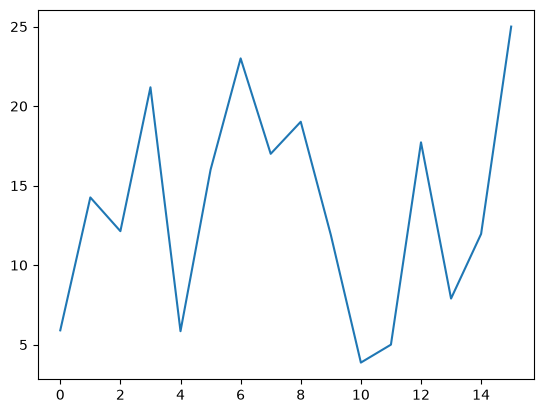

In [11]:
Y_obs, timestamps, active_est_km, codes = load_and_clean_data(csv_path="Estaciones_PM2.5_2026_06.csv", stations_dict=DEFAULT_STATIONS)

import matplotlib.pyplot as plt
plt.plot(Y_obs[-2])